heart disease prediction - ensemble
---------------------------------------------
logistic -> 0.49
random forest -> 0.477
svm -> 0.467
knn -> 0.473
soft voting -> 0.483
stacking -> 0.483
---------------------------------------------
best model: logistic -> 0.49
---------------------------------------------
              precision    recall  f1-score   support

  no disease       0.45      0.70      0.55        27
     disease       0.56      0.30      0.39        33

    accuracy                           0.48        60
   macro avg       0.50      0.50      0.47        60
weighted avg       0.51      0.48      0.46        60



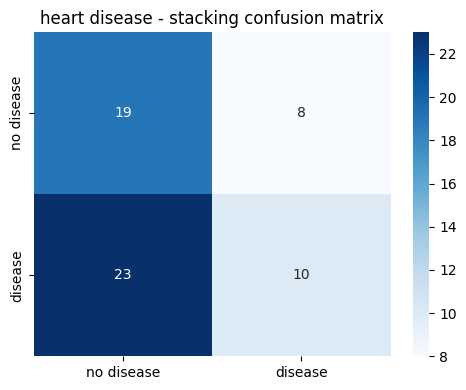

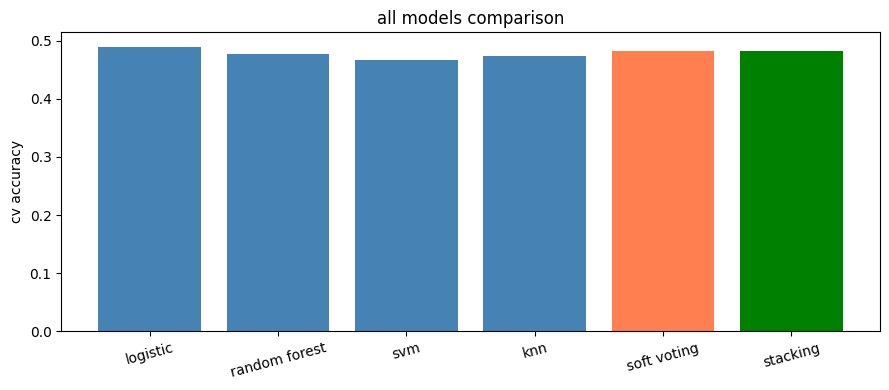

patient prediction: has disease!
confidence: 90.0 %


In [5]:
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

data = {
    "age":          np.random.randint(30, 75, n),
    "bp":           np.random.randint(90, 180, n),
    "cholesterol":  np.random.randint(150, 350, n),
    "heart_rate":   np.random.randint(60, 180, n),
    "blood_sugar":  np.random.choice([0, 1], n),
    "chest_pain":   np.random.randint(0, 4, n),
    "disease":      np.random.choice([0, 1], n, p=[0.55, 0.45])
}

df = pd.DataFrame(data)
x = df.drop("disease", axis=1)
y = df["disease"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

# base models
lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svc = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
gb  = GradientBoostingClassifier(n_estimators=100, random_state=42)

base = [("lr", lr), ("rf", rf), ("svc", svc), ("knn", knn)]

# soft voting
soft_vote = VotingClassifier(estimators=base, voting="soft")

# stacking with gb as meta model
stack = StackingClassifier(
    estimators=base,
    final_estimator=gb,
    cv=5
)

models = {
    "logistic":         lr,
    "random forest":    rf,
    "svm":              svc,
    "knn":              knn,
    "soft voting":      soft_vote,
    "stacking":         stack
}

print("heart disease prediction - ensemble")
print("-" * 45)

scores = {}
for name, model in models.items():
    cv = round(np.mean(cross_val_score(model, x_scaled, y, cv=5)), 3)
    scores[name] = cv
    print(name, "->", cv)

# best model
best_name = max(scores, key=scores.get)
print("-" * 45)
print("best model:", best_name, "->", scores[best_name])

# train best model and evaluate
stack.fit(x_train, y_train)
y_pred = stack.predict(x_test)

print("-" * 45)
print(classification_report(y_test, y_pred,
      target_names=["no disease", "disease"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no disease", "disease"],
            yticklabels=["no disease", "disease"])
plt.title("heart disease - stacking confusion matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
colors = ["steelblue"] * 4 + ["coral", "green"]
plt.bar(scores.keys(), scores.values(), color=colors)
plt.title("all models comparison")
plt.ylabel("cv accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

new_patient = [[55, 140, 260, 150, 1, 2]]
result = stack.predict(new_patient)
prob = stack.predict_proba(new_patient)
print("patient prediction:",
      "has disease!" if result[0] == 1 else "healthy")
print("confidence:", round(max(prob[0]) * 100, 1), "%")